<a href="https://colab.research.google.com/github/LaraDondossola/Classificacao-eventos-climaticos/blob/main/Notebooks/Limpeza_e_Pr%C3%A9_processamento.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

✅ Bibliotecas carregadas com sucesso!
✅ Arquivo carregado com sucesso!

--- TREINANDO MODELOS DE REGRESSÃO ---

=== TABELA DE MÉTRICAS COMPARAÇÃO ===


,Modelo de Regressão,MAE (Pessoas),RMSE (Pessoas),R² (Escala Log)
0,Regressão Múltipla,32303.18,237778.56,0.5326
1,KNN Regressor (K=15),8438.63,85673.35,0.6748
2,Random Forest Regressor,8005.80,71545.91,0.7584


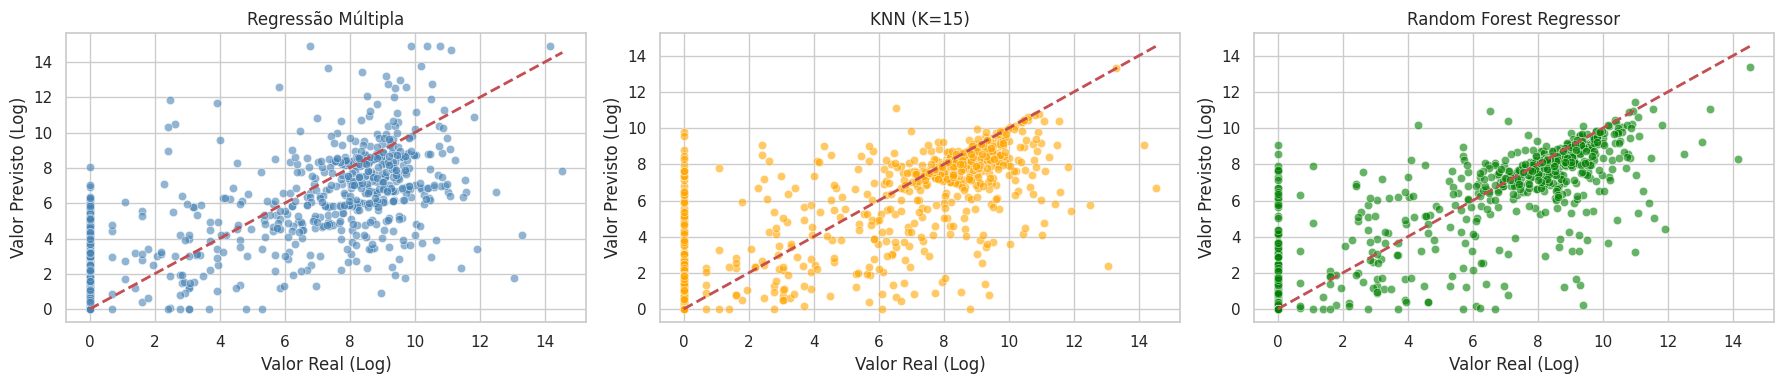

In [ ]:
# ==============================================================================
# PROJETO: Estimativa de Eventos Climáticos Extremos
# ==============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (15, 4)

print("✅ Bibliotecas carregadas com sucesso!")

# ==============================================================================
# 1. CARREGAMENTO E LIMPEZA
# ==============================================================================

try:
    df = pd.read_excel('Danos_Informados.xlsx')
    print("✅ Arquivo carregado com sucesso!")
except FileNotFoundError:
    print("⚠️ Arquivo 'Danos_Informados.xlsx' não encontrado.")

df = df.drop_duplicates().reset_index(drop=True)
if 'UF' in df.columns:
    df['UF'] = df['UF'].astype(str).str.upper().str.strip()

if 'DH_Mortos' in df.columns and 'População' in df.columns:
    inconsistentes = df['DH_Mortos'] > df['População']
    if inconsistentes.sum() > 0:
        df.loc[inconsistentes, 'DH_Mortos'] = df.loc[inconsistentes, 'População']

colunas_contagem = ['DH_Mortos', 'DH_Desabrigados', 'DH_Desalojados', 'DH_Feridos',
                    'DH_Enfermos', 'DH_Desaparecidos', 'DH_Outros Afetados']

for col in colunas_contagem:
    if col in df.columns:
        df[col] = df[col].fillna(0)

if 'População' in df.columns and df['População'].isnull().sum() > 0:
    df['População'] = df['População'].fillna(df['População'].median())

colunas_ambientais = [col for col in df.columns if col.startswith('DA_')]
for col in colunas_ambientais:
    df[col] = df[col].fillna('Não Informado').astype(str)

# ==============================================================================
# 2. FEATURE ENGINEERING E TRANSFORMAÇÃO LOG
# ==============================================================================

df['DH_Total_Direto'] = df[['DH_Mortos', 'DH_Feridos', 'DH_Enfermos', 'DH_Desabrigados', 'DH_Desalojados', 'DH_Desaparecidos']].sum(axis=1)
df['População_Afetada_Total'] = df['DH_Total_Direto'] + df['DH_Outros Afetados']

col_mat = [col for col in df.columns if col.startswith('DM_') and 'Valor' in col]
col_pub = [col for col in df.columns if col.startswith('PEPL_')]
col_priv = [col for col in df.columns if col.startswith('PEPR_')]
df['Prejuizo_Financeiro_Total'] = df[col_mat + col_pub + col_priv].sum(axis=1)

if 'COBRADE' in df.columns:
    df['Tipo_Evento'] = df['COBRADE'].astype(str).str.split(' - ').str[1].fillna('Outros').str.strip()

# Atributo não-linear de escala populacional (Sem data leakage)
if 'População' in df.columns:
    df['Log_Populacao'] = np.log1p(df['População'])

features_para_remover = [
    'Registro', 'Protocolo', 'Município', 'Status', 'COBRADE',
    'População_Afetada_Total', 'DH_Total_Direto',
    'DH_Mortos', 'DH_Feridos', 'DH_Enfermos', 'DH_Desabrigados',
    'DH_Desalojados', 'DH_Desaparecidos', 'DH_Outros Afetados',
    'Prejuizo_Financeiro_Total'
]

X = df.drop(columns=[col for col in features_para_remover if col in df.columns])
y_reg = df['População_Afetada_Total']

y_reg_log = np.log1p(y_reg)

# Divisão dos dados
X_train, X_temp, y_train_log, y_temp_log, y_train_real, y_temp_real = train_test_split(
    X, y_reg_log, y_reg, test_size=0.30, random_state=42
)
X_val, X_test, y_val_log, y_test_log, y_val_real, y_test_real = train_test_split(
    X_temp, y_temp_log, y_temp_real, test_size=0.50, random_state=42
)

# Pré-processamento
num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
    ]
)

X_train_prep = preprocessor.fit_transform(X_train)
X_val_prep = preprocessor.transform(X_val)
X_test_prep = preprocessor.transform(X_test)

# ==============================================================================
# 3. TREINAMENTO DOS MODELOS
# ==============================================================================

print("\n--- TREINANDO MODELOS DE REGRESSÃO ---")

# 1. Regressão Múltipla
reg_multipla = LinearRegression()
reg_multipla.fit(X_train_prep, y_train_log)
pred_multipla_log = np.clip(reg_multipla.predict(X_test_prep), 0, y_train_log.max())
y_pred_multipla = np.expm1(pred_multipla_log)

# 2. KNN Regressor (Grade Expandida com weights='distance')
param_grid_knn = {
    'n_neighbors': [1, 2, 3, 5, 7, 9, 11, 15],
    'weights': ['distance', 'uniform'],
    'metric': ['euclidean', 'manhattan']
}

grid_knn_reg = GridSearchCV(
    KNeighborsRegressor(),
    param_grid_knn,
    cv=5,
    scoring='r2',
    n_jobs=-1
)
grid_knn_reg.fit(X_train_prep, y_train_log)

best_knn_reg = grid_knn_reg.best_estimator_
pred_knn_log = best_knn_reg.predict(X_test_prep)
y_pred_knn = np.expm1(pred_knn_log)

# 3. Random Forest Regressor
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_reg.fit(X_train_prep, y_train_log)
pred_rf_log = rf_reg.predict(X_test_prep)
y_pred_rf = np.expm1(pred_rf_log)

# ==============================================================================
# 4. AVALIAÇÃO DE MÉTRICAS E GRÁFICOS
# ==============================================================================

def metricas_reg(y_true_real, y_pred_real, y_true_log, y_pred_log, nome):
    return {
        'Modelo de Regressão': nome,
        'MAE (Pessoas)': f"{mean_absolute_error(y_true_real, y_pred_real):.2f}",
        'RMSE (Pessoas)': f"{np.sqrt(mean_squared_error(y_true_real, y_pred_real)):.2f}",
        'R² (Escala Log)': f"{r2_score(y_true_log, y_pred_log):.4f}"
    }

df_res_reg = pd.DataFrame([
    metricas_reg(y_test_real, y_pred_multipla, y_test_log, pred_multipla_log, "Regressão Múltipla"),
    metricas_reg(y_test_real, y_pred_knn, y_test_log, pred_knn_log, f"KNN Regressor (K={grid_knn_reg.best_params_['n_neighbors']})"),
    metricas_reg(y_test_real, y_pred_rf, y_test_log, pred_rf_log, "Random Forest Regressor")
])

print("\n=== TABELA DE MÉTRICAS COMPARAÇÃO ===")
display(df_res_reg)

# Gráficos
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# Regressão Múltipla
sns.scatterplot(x=y_test_log, y=pred_multipla_log, ax=axes[0], alpha=0.6, color='steelblue')
axes[0].plot([y_test_log.min(), y_test_log.max()], [y_test_log.min(), y_test_log.max()], 'r--', lw=2)
axes[0].set_title('Regressão Múltipla')
axes[0].set_xlabel('Valor Real (Log)')
axes[0].set_ylabel('Valor Previsto (Log)')

# KNN
sns.scatterplot(x=y_test_log, y=pred_knn_log, ax=axes[1], alpha=0.6, color='orange')
axes[1].plot([y_test_log.min(), y_test_log.max()], [y_test_log.min(), y_test_log.max()], 'r--', lw=2)
axes[1].set_title(f"KNN (K={grid_knn_reg.best_params_['n_neighbors']})")
axes[1].set_xlabel('Valor Real (Log)')
axes[1].set_ylabel('Valor Previsto (Log)')

# Random Forest
sns.scatterplot(x=y_test_log, y=pred_rf_log, ax=axes[2], alpha=0.6, color='green')
axes[2].plot([y_test_log.min(), y_test_log.max()], [y_test_log.min(), y_test_log.max()], 'r--', lw=2)
axes[2].set_title('Random Forest Regressor')
axes[2].set_xlabel('Valor Real (Log)')
axes[2].set_ylabel('Valor Previsto (Log)')

plt.tight_layout()
plt.show()

/tmp/ipykernel_461/1041155584.py:9: RuntimeWarning: divide by zero encountered in scalar divide
  pct = (y_pessoas / pop_total) * 100


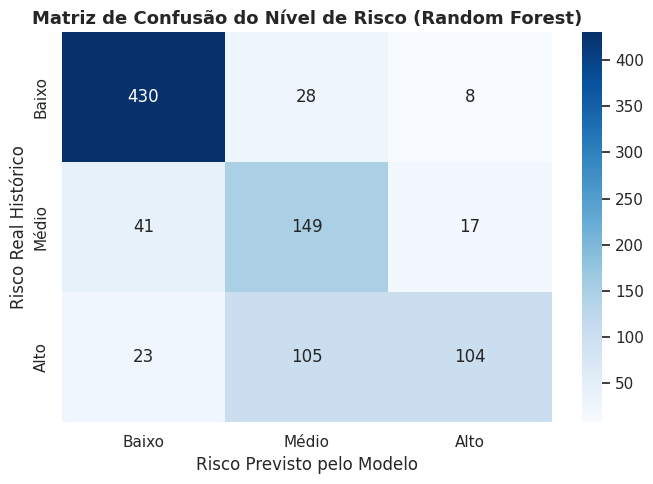

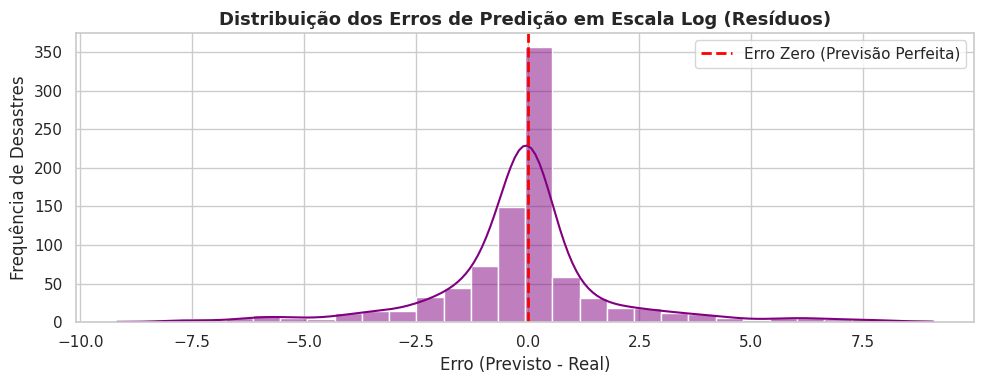

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# ==============================================================================
# GRÁFICO 1: MATRIZ DE CONFUSÃO DOS NÍVEIS DE RISCO (Falsos Positivos/Negativos)
# ==============================================================================

# Função para categorizar em Risco (conforme cortes do seu projeto: 3.6% e 50.2%)
def classificar_nivel_risco(y_pessoas, pop_total):
    pct = (y_pessoas / pop_total) * 100
    if pct < 3.6034:
        return 'Baixo'
    elif pct <= 50.1603:
        return 'Médio'
    else:
        return 'Alto'

# Pegar a população do conjunto de teste
pop_test = X_test['População'].values

# Converter Real e Previsto (Random Forest) para Categorias de Risco
y_real_risco = [classificar_nivel_risco(r, p) for r, p in zip(y_test_real, pop_test)]
y_pred_rf_risco = [classificar_nivel_risco(p_est, p) for p_est, p in zip(y_pred_rf, pop_test)]

labels = ['Baixo', 'Médio', 'Alto']
cm = confusion_matrix(y_real_risco, y_pred_rf_risco, labels=labels)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.title('Matriz de Confusão do Nível de Risco (Random Forest)', fontsize=13, fontweight='bold')
plt.xlabel('Risco Previsto pelo Modelo')
plt.ylabel('Risco Real Histórico')
plt.tight_layout()
plt.show()


# ==============================================================================
# GRÁFICO 2: DISTRIBUIÇÃO DOS ERROS / RESÍDUOS (Superestimação vs Subestimação)
# ==============================================================================

residuos_rf = pred_rf_log - y_test_log

plt.figure(figsize=(10, 4))
sns.histplot(residuos_rf, kde=True, color='purple', bins=30)
plt.axvline(0, color='red', linestyle='--', linewidth=2, label='Erro Zero (Previsão Perfeita)')
plt.title('Distribuição dos Erros de Predição em Escala Log (Resíduos)', fontsize=13, fontweight='bold')
plt.xlabel('Erro (Previsto - Real)')
plt.ylabel('Frequência de Desastres')
plt.legend()
plt.tight_layout()
plt.show()


✅ Bibliotecas carregadas com sucesso!
✅ Arquivo 'Danos_Informados.xlsx' carregado com sucesso!

--- TREINANDO MODELOS DE REGRESSÃO OTIMIZADOS ---
✅ Melhor configuração KNN: {'algorithm': 'auto', 'metric': 'manhattan', 'n_neighbors': 15, 'weights': 'distance'}
✅ Melhor configuração Random Forest: {'max_depth': 25, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}

✅ Artefatos 'preprocessor.pkl', 'modelo_knn_regressor.pkl' e 'modelo_random_forest.pkl' salvos com sucesso!

=== TABELA COMPARATIVA DE MÉTRICAS ===


,Modelo de Regressão,MAE (Pessoas),RMSE (Pessoas),R² (Escala Log)
0,Regressão Múltipla,30861.52,227150.82,0.5130
1,KNN Regressor (K=15),7660.81,65692.43,0.6750
2,Random Forest Regressor,9686.21,94839.79,0.7591


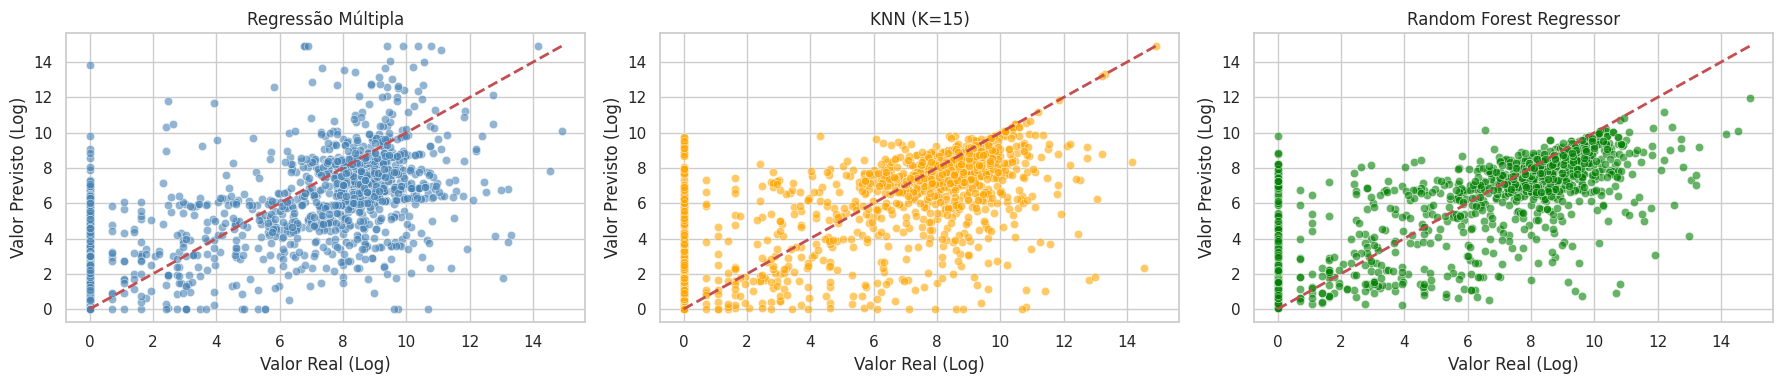

In [1]:
# ==============================================================================
# PROJETO: Estimativa de Eventos Climáticos Extremos (Código Completo Otimizado)
# ==============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (15, 4)

print("✅ Bibliotecas carregadas com sucesso!")

# ==============================================================================
# 1. CARREGAMENTO E LIMPEZA DOS DADOS
# ==============================================================================

try:
    df = pd.read_excel('Danos_Informados.xlsx')
    print("✅ Arquivo 'Danos_Informados.xlsx' carregado com sucesso!")
except FileNotFoundError:
    print("⚠️ Arquivo 'Danos_Informados.xlsx' não encontrado. Verifique o caminho.")

# Remoção de duplicatas
df = df.drop_duplicates().reset_index(drop=True)

# Padronização da sigla do Estado
if 'UF' in df.columns:
    df['UF'] = df['UF'].astype(str).str.upper().str.strip()

# Tratar valores inconsistentes de mortos (mortos > população)
if 'DH_Mortos' in df.columns and 'População' in df.columns:
    inconsistentes = df['DH_Mortos'] > df['População']
    if inconsistentes.sum() > 0:
        df.loc[inconsistentes, 'DH_Mortos'] = df.loc[inconsistentes, 'População']

# Preenchimento de nulos em variáveis numéricas
num_cols_raw = df.select_dtypes(include=[np.number]).columns
df[num_cols_raw] = df[num_cols_raw].fillna(0)

# Tratar populações zeradas ou ausentes usando a mediana das populações válidas
if 'População' in df.columns:
    median_pop = df[df['População'] > 0]['População'].median()
    df['População'] = df['População'].replace(0, median_pop)

# Preenchimento das variáveis ambientais categóricas
colunas_ambientais = [col for col in df.columns if col.startswith('DA_')]
for col in colunas_ambientais:
    df[col] = df[col].fillna('Não Informado').astype(str)

# ==============================================================================
# 2. FEATURE ENGINEERING E TRANSFORMAÇÕES
# ==============================================================================

# Criação do Alvo (Total de Pessoas Afetadas)
colunas_humanos = ['DH_Mortos', 'DH_Feridos', 'DH_Enfermos', 'DH_Desabrigados', 'DH_Desalojados', 'DH_Desaparecidos', 'DH_Outros Afetados']
df['População_Afetada_Total'] = df[[col for col in colunas_humanos if col in df.columns]].sum(axis=1)

# Agregações de Engenharia de Recursos para Estruturas
cols_danificadas = [c for c in df.columns if 'Danificadas' in c and c != 'População_Afetada_Total']
cols_destruidas = [c for c in df.columns if 'Destruídas' in c and c != 'População_Afetada_Total']

df['Total_Estruturas_Danificadas'] = df[cols_danificadas].sum(axis=1)
df['Total_Estruturas_Destruidas'] = df[cols_destruidas].sum(axis=1)

# Extração da tipologia do evento COBRADE
if 'COBRADE' in df.columns:
    df['Tipo_Evento'] = df['COBRADE'].astype(str).str.split(' - ').str[1].fillna('Outros').str.strip()

# Transformação não-linear para escala populacional
if 'População' in df.columns:
    df['Log_Populacao'] = np.log1p(df['População'])

# Remoção rigorosa de variáveis que causam Vazamento de Dados (Data Leakage) e identificadores
features_para_remover = [
    'Registro', 'Protocolo', 'Município', 'Status', 'COBRADE',
    'População_Afetada_Total', 'DH_Total_Direto',
    'DH_Mortos', 'DH_Feridos', 'DH_Enfermos', 'DH_Desabrigados',
    'DH_Desalojados', 'DH_Desaparecidos', 'DH_Outros Afetados',
    'Prejuizo_Financeiro_Total'
]

X = df.drop(columns=[col for col in features_para_remover if col in df.columns])
y_reg = df['População_Afetada_Total']

# Transformação Logarítmica no Alvo para mitigar o impacto de superdesastres
y_reg_log = np.log1p(y_reg)

# Divisão Treino (70%) e Teste (30%)
X_train, X_test, y_train_log, y_test_log, y_train_real, y_test_real = train_test_split(
    X, y_reg_log, y_reg, test_size=0.30, random_state=42
)

# Pré-processamento: RobustScaler para variáveis numéricas e OneHotEncoder para categóricas
num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', RobustScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
    ]
)

X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep = preprocessor.transform(X_test)

# ==============================================================================
# 3. TREINAMENTO E OTIMIZAÇÃO DOS MODELOS (GRIDSEARCH)
# ==============================================================================

print("\n--- TREINANDO MODELOS DE REGRESSÃO OTIMIZADOS ---")

# 1. Regressão Múltipla (Modelo Baseline)
reg_multipla = LinearRegression()
reg_multipla.fit(X_train_prep, y_train_log)
pred_multipla_log = np.clip(reg_multipla.predict(X_test_prep), 0, y_train_log.max())
y_pred_multipla = np.expm1(pred_multipla_log)

# 2. KNN Regressor (Grade com ponderação por distância e métrica Manhattan)
param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9, 11, 15],
    'weights': ['distance'],
    'metric': ['manhattan', 'euclidean'],
    'algorithm': ['auto', 'ball_tree']
}

grid_knn_reg = GridSearchCV(
    KNeighborsRegressor(),
    param_grid_knn,
    cv=5,
    scoring='r2',
    n_jobs=-1
)
grid_knn_reg.fit(X_train_prep, y_train_log)

best_knn_reg = grid_knn_reg.best_estimator_
pred_knn_log = best_knn_reg.predict(X_test_prep)
y_pred_knn = np.expm1(pred_knn_log)

# 3. Random Forest Regressor (Tuning com Validação Cruzada)
param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [15, 25, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 0.5]
}

grid_rf_reg = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid_rf,
    cv=5,
    scoring='r2',
    n_jobs=-1
)
grid_rf_reg.fit(X_train_prep, y_train_log)

best_rf_reg = grid_rf_reg.best_estimator_
pred_rf_log = best_rf_reg.predict(X_test_prep)
y_pred_rf = np.expm1(pred_rf_log)

print(f"✅ Melhor configuração KNN: {grid_knn_reg.best_params_}")
print(f"✅ Melhor configuração Random Forest: {grid_rf_reg.best_params_}")

# ==============================================================================
# 4. SALVAMENTO DOS ARTEFATOS (.PKL)
# ==============================================================================

joblib.dump(preprocessor, 'preprocessor.pkl')
joblib.dump(best_knn_reg, 'modelo_knn_regressor.pkl')
joblib.dump(best_rf_reg, 'modelo_random_forest.pkl')

print("\n✅ Artefatos 'preprocessor.pkl', 'modelo_knn_regressor.pkl' e 'modelo_random_forest.pkl' salvos com sucesso!")

# ==============================================================================
# 5. AVALIAÇÃO DE MÉTRICAS E VISUALIZAÇÃO DOS RESULTADOS
# ==============================================================================

def metricas_reg(y_true_real, y_pred_real, y_true_log, y_pred_log, nome):
    return {
        'Modelo de Regressão': nome,
        'MAE (Pessoas)': f"{mean_absolute_error(y_true_real, y_pred_real):.2f}",
        'RMSE (Pessoas)': f"{np.sqrt(mean_squared_error(y_true_real, y_pred_real)):.2f}",
        'R² (Escala Log)': f"{r2_score(y_true_log, y_pred_log):.4f}"
    }

df_res_reg = pd.DataFrame([
    metricas_reg(y_test_real, y_pred_multipla, y_test_log, pred_multipla_log, "Regressão Múltipla"),
    metricas_reg(y_test_real, y_pred_knn, y_test_log, pred_knn_log, f"KNN Regressor (K={grid_knn_reg.best_params_['n_neighbors']})"),
    metricas_reg(y_test_real, y_pred_rf, y_test_log, pred_rf_log, "Random Forest Regressor")
])

print("\n=== TABELA COMPARATIVA DE MÉTRICAS ===")
display(df_res_reg)

# Gráficos Comparativos de Previsão vs Valor Real em Escala Log
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# Regressão Múltipla
sns.scatterplot(x=y_test_log, y=pred_multipla_log, ax=axes[0], alpha=0.6, color='steelblue')
axes[0].plot([y_test_log.min(), y_test_log.max()], [y_test_log.min(), y_test_log.max()], 'r--', lw=2)
axes[0].set_title('Regressão Múltipla')
axes[0].set_xlabel('Valor Real (Log)')
axes[0].set_ylabel('Valor Previsto (Log)')

# KNN Otimizado
sns.scatterplot(x=y_test_log, y=pred_knn_log, ax=axes[1], alpha=0.6, color='orange')
axes[1].plot([y_test_log.min(), y_test_log.max()], [y_test_log.min(), y_test_log.max()], 'r--', lw=2)
axes[1].set_title(f"KNN (K={grid_knn_reg.best_params_['n_neighbors']})")
axes[1].set_xlabel('Valor Real (Log)')
axes[1].set_ylabel('Valor Previsto (Log)')

# Random Forest Otimizado
sns.scatterplot(x=y_test_log, y=pred_rf_log, ax=axes[2], alpha=0.6, color='green')
axes[2].plot([y_test_log.min(), y_test_log.max()], [y_test_log.min(), y_test_log.max()], 'r--', lw=2)
axes[2].set_title('Random Forest Regressor')
axes[2].set_xlabel('Valor Real (Log)')
axes[2].set_ylabel('Valor Previsto (Log)')

plt.tight_layout()
plt.show()

In [2]:
# ==============================================================================
# INSPEÇÃO DE OUTLIERS E MAIORES ERROS DE PREVISÃO (ESCALA REAL)
# ==============================================================================

# DataFrame de inspeção no conjunto de teste com o nome do município
df_outliers = pd.DataFrame({
    'Cidade': df.loc[X_test.index, 'Município'],
    'UF': df.loc[X_test.index, 'UF'] if 'UF' in df.columns else '',
    'Valor_Real': y_test_real,

    'Pred_Reg_Multipla': y_pred_multipla,
    'Erro_Abs_Multipla': np.abs(y_test_real - y_pred_multipla),

    'Pred_KNN': y_pred_knn,
    'Erro_Abs_KNN': np.abs(y_test_real - y_pred_knn),

    'Pred_Random_Forest': y_pred_rf,
    'Erro_Abs_RF': np.abs(y_test_real - y_pred_rf)
})

# 1. Registro com o maior valor real (Outlier Extremo da Base)
print("=== REGISTRO COM O MAIOR VALOR REAL (População Afetada Extrema) ===")
maior_real = df_outliers.sort_values(by='Valor_Real', ascending=False).head(1)
display(maior_real)

# 2. Top 3 Maiores Erros na Regressão Múltipla
print("\n=== TOP 3 MAIORES DISCREPÂNCIAS (Regressão Múltipla) ===")
display(df_outliers.sort_values(by='Erro_Abs_Multipla', ascending=False)[
    ['Cidade', 'UF', 'Valor_Real', 'Pred_Reg_Multipla', 'Erro_Abs_Multipla']
].head(3))

# 3. Top 3 Maiores Erros no KNN Regressor
print("\n=== TOP 3 MAIORES DISCREPÂNCIAS (KNN Regressor) ===")
display(df_outliers.sort_values(by='Erro_Abs_KNN', ascending=False)[
    ['Cidade', 'UF', 'Valor_Real', 'Pred_KNN', 'Erro_Abs_KNN']
].head(3))

# 4. Top 3 Maiores Erros no Random Forest
print("\n=== TOP 3 MAIORES DISCREPÂNCIAS (Random Forest Regressor) ===")
display(df_outliers.sort_values(by='Erro_Abs_RF', ascending=False)[
    ['Cidade', 'UF', 'Valor_Real', 'Pred_Random_Forest', 'Erro_Abs_RF']
].head(3))

=== REGISTRO COM O MAIOR VALOR REAL (População Afetada Extrema) ===


,Cidade,UF,Valor_Real,Pred_Reg_Multipla,Erro_Abs_Multipla,Pred_KNN,Erro_Abs_KNN,Pred_Random_Forest,Erro_Abs_RF
3694,Brasília,DF,2982818.0,23819.352832,2.958999e+06,2982818.0,9.313226e-10,154769.317739,2.828049e+06



=== TOP 3 MAIORES DISCREPÂNCIAS (Regressão Múltipla) ===


,Cidade,UF,Valor_Real,Pred_Reg_Multipla,Erro_Abs_Multipla
1966,Presidente Figueiredo,AM,881.0,2982818.0,2981937.0
561,Santa Luzia do Pará,PA,897.0,2982818.0,2981921.0
3914,Camaquã,RS,1000.0,2982818.0,2981818.0



=== TOP 3 MAIORES DISCREPÂNCIAS (KNN Regressor) ===


,Cidade,UF,Valor_Real,Pred_KNN,Erro_Abs_KNN
1087,Manaus,AM,2063547.0,9.088130,2.063538e+06
5681,Porto Alegre,RS,1409000.0,4259.947817,1.404740e+06
2104,Juiz de Fora,MG,540756.0,6636.452610,5.341195e+05



=== TOP 3 MAIORES DISCREPÂNCIAS (Random Forest Regressor) ===


,Cidade,UF,Valor_Real,Pred_Random_Forest,Erro_Abs_RF
3694,Brasília,DF,2982818.0,154769.317739,2.828049e+06
1087,Manaus,AM,2063547.0,24633.627460,2.038913e+06
5681,Porto Alegre,RS,1409000.0,20753.685356,1.388246e+06


In [ ]:
import joblib
from google.colab import files

# ==============================================================================
# SALVANDO E FAZENDO DOWNLOAD DOS MODELOS E DO PRÉ-PROCESSADOR
# ==============================================================================

# 1. Salvando os arquivos localmente no ambiente do Colab
joblib.dump(preprocessor, 'preprocessor.pkl')
joblib.dump(best_knn_reg, 'modelo_knn_regressor.pkl')
joblib.dump(rf_reg, 'modelo_random_forest.pkl')

print("✅ Arquivos gerados no ambiente local. Iniciando download para o seu computador...")

# 2. Fazendo o download direto para a sua pasta de Downloads do computador
files.download('preprocessor.pkl')
files.download('modelo_knn_regressor.pkl')
files.download('modelo_random_forest.pkl')